# Dashboard y Visualización de Resultados
# Trabajo Fin de Máster

## Business Analytics aplicado a FOOD&FUN: análisis, predicción y optimización para la toma de decisiones

**Autora:** Francisca Concha

**Máster en Business Analytics e Inteligencia de Negocio**

**Universidad Católica de Valencia**

**Curso académico 2025–2026**




Una vez desarrollados los modelos de predicción de demanda, predicción de ocupación y optimización del calendario mediante Gurobi, se procede a centralizar los principales resultados en un entorno de visualización.

El objetivo de este notebook es generar los archivos y estructuras necesarias para la construcción de un panel de control interactivo que facilite la interpretación de los resultados obtenidos.

In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

# 1. Carga de los resultados generados en los notebooks anteriores

In [28]:
df = pd.read_excel(
    "Compras_2526_F&F.xlsx"
)

df.head()

,Fecha de Compra,Número de Pedido,Taller,Fecha Taller,Cantidad de Plazas,TARJETAS REGALO,Importe Total,IMPORTE DEVOLUCIÓN,Método de Pago
0,2024-11-18,43856526,Tarjeta Regalo,NaN,0,1.0,150.0,NaN,Visa
1,2025-01-01,43861545,Kimchi,2025-03-24 00:00:00,2,NaN,180.0,NaN,Bizum
2,2025-01-01,43861547,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Visa
3,2025-01-01,43861597,Tarjeta Regalo,NaN,0,0.0,0.0,NaN,Devolución
4,2025-01-01,43861549,Ramen,2025-03-28 00:00:00,2,NaN,162.0,NaN,Visa


In [29]:
df.shape

(1409, 9)

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Fecha de Compra     1409 non-null   datetime64[us]
 1   Número de Pedido    1409 non-null   int64         
 2   Taller              1409 non-null   str           
 3   Fecha Taller        1029 non-null   object        
 4   Cantidad de Plazas  1409 non-null   int64         
 5   TARJETAS REGALO     363 non-null    float64       
 6   Importe Total       1409 non-null   float64       
 7   IMPORTE DEVOLUCIÓN  12 non-null     float64       
 8   Método de Pago      1409 non-null   str           
dtypes: datetime64[us](1), float64(3), int64(2), object(1), str(2)
memory usage: 99.2+ KB


In [31]:
df.columns

Index(['Fecha de Compra', 'Número de Pedido', 'Taller', 'Fecha Taller',
       'Cantidad de Plazas', 'TARJETAS REGALO', 'Importe Total',
       'IMPORTE DEVOLUCIÓN', 'Método de Pago'],
      dtype='str')

# 2. Dashboard ejecutivo

Se calculan los principales indicadores de negocio para obtener una visión global de la actividad de Food&Fun durante el periodo analizado.

## KPI's Principales

In [32]:
# Facturación total

facturacion_total = df["Importe Total"].sum()

# Número de pedidos

num_pedidos = df["Número de Pedido"].nunique()

# Plazas vendidas

plazas_vendidas = df["Cantidad de Plazas"].sum()

# Ticket medio

ticket_medio = (
    df["Importe Total"].sum()
    / df["Número de Pedido"].nunique()
)

# Número de talleres distintos

num_talleres = df["Taller"].nunique()

# Mostrar resultados

print(f"Facturación total: {facturacion_total:,.2f} €")
print(f"Número de pedidos: {num_pedidos}")
print(f"Plazas vendidas: {plazas_vendidas}")
print(f"Ticket medio: {ticket_medio:.2f} €")
print(f"Talleres distintos: {num_talleres}")

Facturación total: 149,297.75 €
Número de pedidos: 1288
Plazas vendidas: 1595
Ticket medio: 115.91 €
Talleres distintos: 18


In [33]:
kpis = pd.DataFrame({
    "Indicador": [
        "Facturación Total (€)",
        "Número de Pedidos",
        "Plazas Vendidas",
        "Ticket Medio (€)",
        "Talleres Distintos"
    ],
    "Valor": [
        round(facturacion_total, 2),
        num_pedidos,
        plazas_vendidas,
        round(ticket_medio, 2),
        num_talleres
    ]
})

kpis

,Indicador,Valor
0,Facturación Total (€),149297.75
1,Número de Pedidos,1288.00
2,Plazas Vendidas,1595.00
3,Ticket Medio (€),115.91
4,Talleres Distintos,18.00


### Facturación por taller

In [34]:
facturacion_taller = (
    df.groupby("Taller")["Importe Total"]
    .sum()
    .sort_values(ascending=False)
)

facturacion_taller.head(10)

Taller
Tarjeta Regalo             33500.00
Curso de Arroces           20570.00
Sushi                      17360.00
Paella Lovers              15875.00
Ramen                      11542.00
Tapas Españolas            11392.75
Raíces                      9410.00
Kimchi                      8050.00
Taller de Pasta Fresca      5930.00
Taller de Principiantes     4863.00
Name: Importe Total, dtype: float64

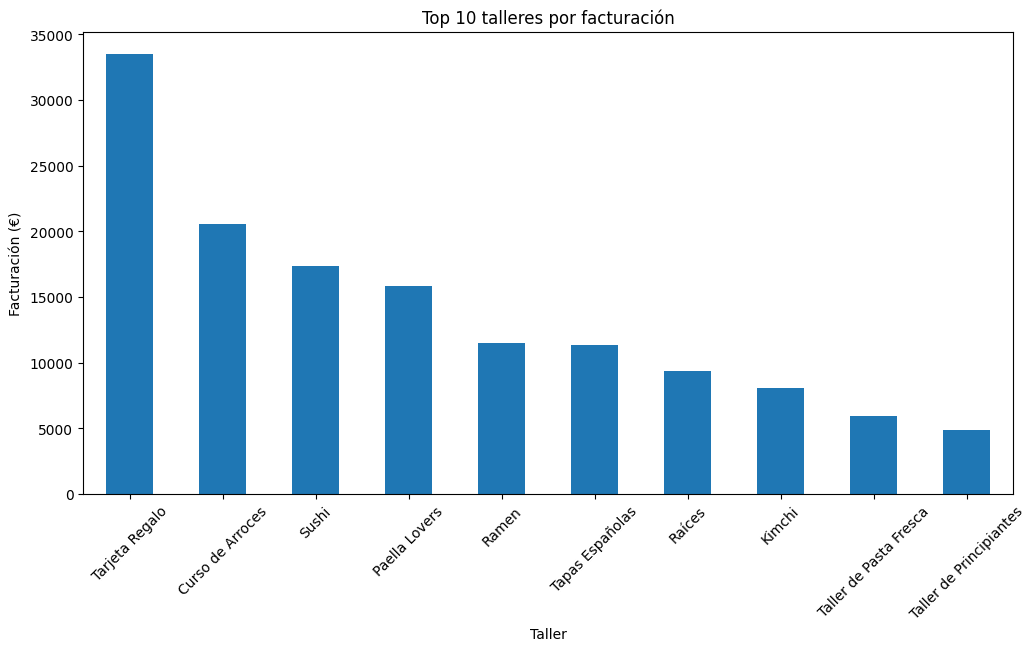

In [35]:
plt.figure(figsize=(12,6))

facturacion_taller.head(10).plot(
    kind="bar"
)

plt.title(
    "Top 10 talleres por facturación"
)

plt.ylabel("Facturación (€)")

plt.xticks(rotation=45)

plt.show()

In [36]:
plazas_taller = (
    df.groupby("Taller")["Cantidad de Plazas"]
    .sum()
    .sort_values(ascending=False)
)

plazas_taller.head(10)

Taller
Curso de Arroces           314
Paella Lovers              247
Sushi                      220
Ramen                      159
Tapas Españolas            146
Raíces                     124
Kimchi                     104
Taller de Pasta Fresca      75
Reposteria                  62
Taller de Principiantes     32
Name: Cantidad de Plazas, dtype: int64

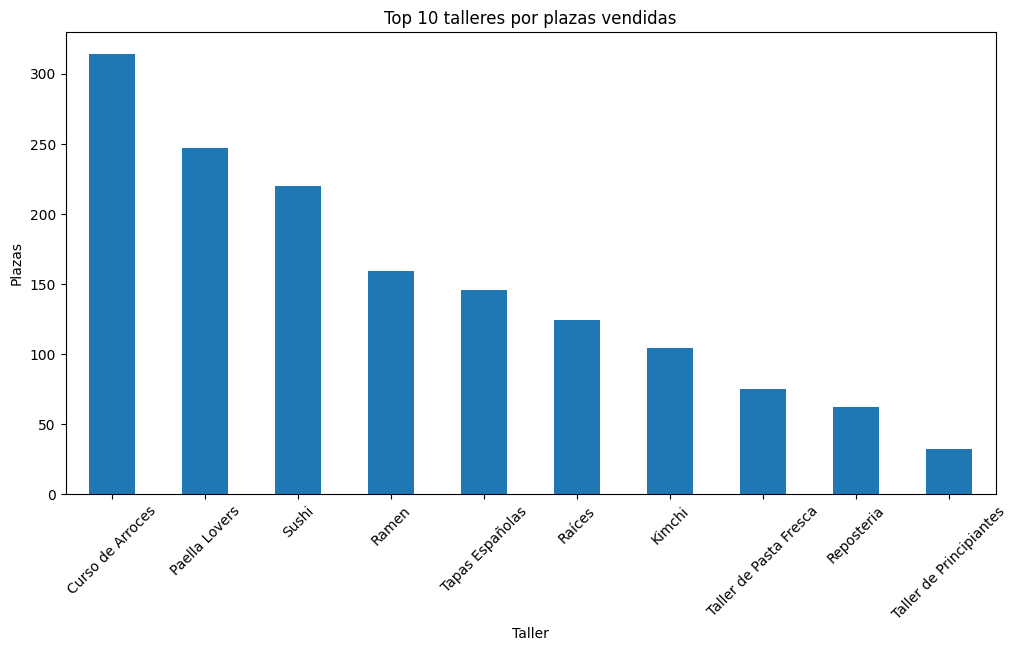

In [37]:
plt.figure(figsize=(12,6))

plazas_taller.head(10).plot(
    kind="bar"
)

plt.title(
    "Top 10 talleres por plazas vendidas"
)

plt.ylabel("Plazas")

plt.xticks(rotation=45)

plt.show()

In [38]:
metodos_pago = (
    df["Método de Pago"]
    .value_counts()
)

metodos_pago

Método de Pago
Stripe                       414
Visa                         391
Bizum                        219
Tarjeta Regalo (canjeado)    199
Devolución                    48
Google Pay                    39
Datafono                      36
Square                        25
Efectivo                      17
Shopify                       10
Transferência                  6
CANCELADO                      5
Name: count, dtype: int64

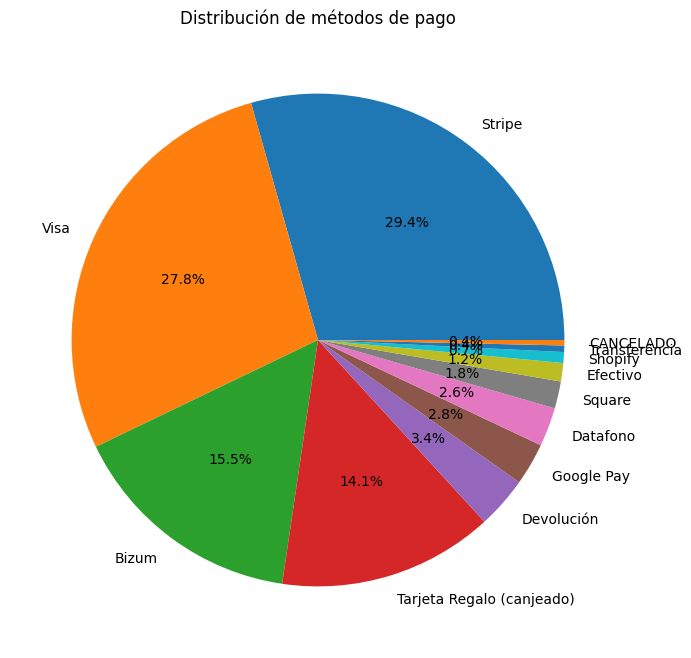

In [39]:
plt.figure(figsize=(8,8))

metodos_pago.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title(
    "Distribución de métodos de pago"
)

plt.show()

# 3. Análisis temporal de ventas

Con el objetivo de identificar patrones estacionales y periodos de mayor actividad, se analiza la evolución temporal de la facturación, el número de pedidos y las plazas vendidas.

In [40]:
# Conversión a fecha

df["Fecha de Compra"] = pd.to_datetime(
    df["Fecha de Compra"]
)

# Año y mes

df["Año"] = df["Fecha de Compra"].dt.year

df["Mes"] = df["Fecha de Compra"].dt.month

df["Periodo"] = (
    df["Fecha de Compra"]
    .dt.to_period("M")
)

In [41]:
# Evolución mensual de la facturación
facturacion_mensual = (
    df.groupby("Periodo")["Importe Total"]
    .sum()
)

facturacion_mensual.head()

Periodo
2024-11      150.0
2025-01    14993.0
2025-02     9050.0
2025-03     8500.0
2025-04     8560.0
Freq: M, Name: Importe Total, dtype: float64

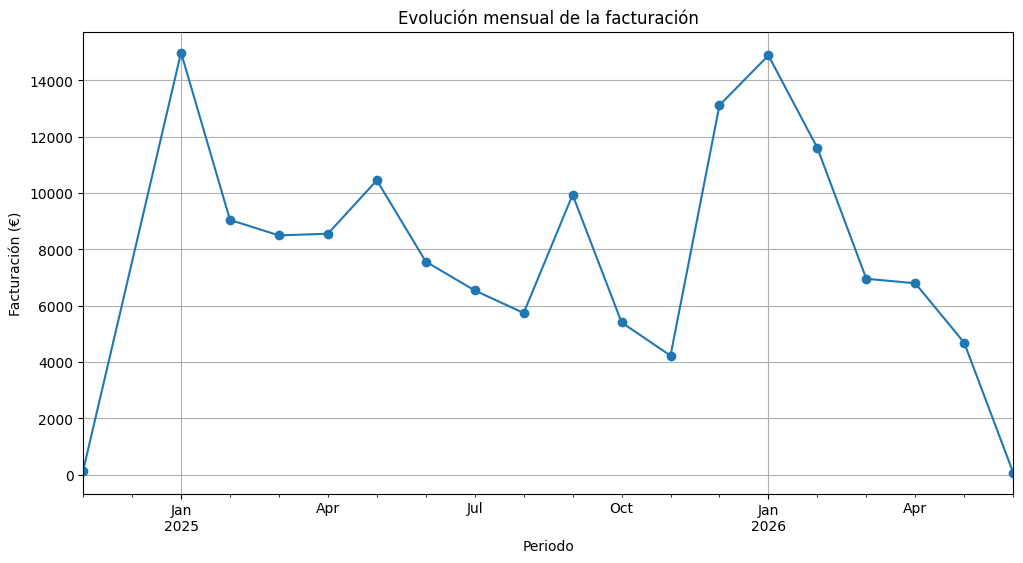

In [42]:
plt.figure(figsize=(12,6))

facturacion_mensual.plot(
    marker="o"
)

plt.title(
    "Evolución mensual de la facturación"
)

plt.xlabel("Periodo")

plt.ylabel("Facturación (€)")

plt.grid(True)

plt.show()

In [43]:
# Evolución mensual del número de pedidos
pedidos_mensuales = (
    df.groupby("Periodo")["Número de Pedido"]
    .nunique()
)

pedidos_mensuales.head()

Periodo
2024-11      1
2025-01    144
2025-02     82
2025-03     78
2025-04     80
Freq: M, Name: Número de Pedido, dtype: int64

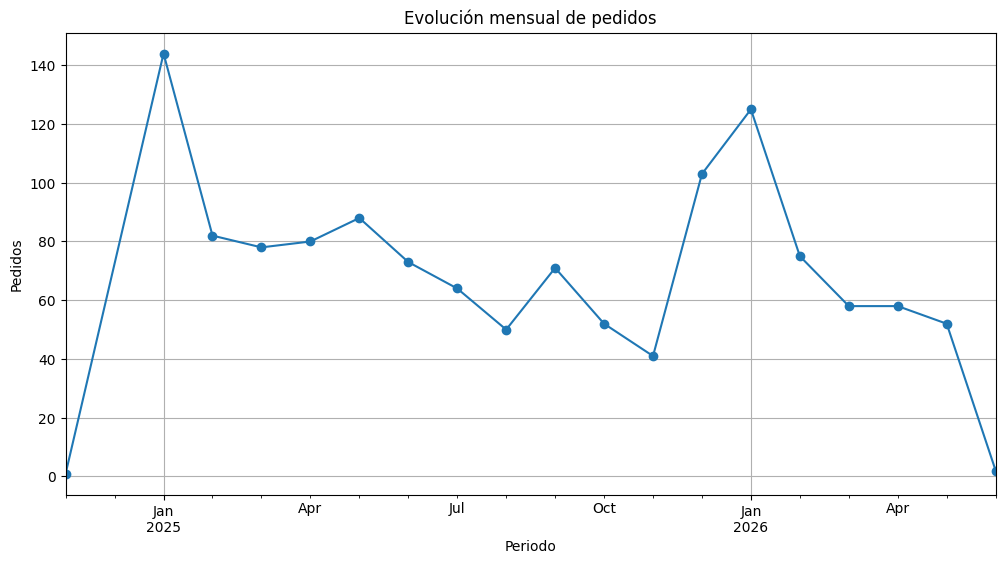

In [44]:
plt.figure(figsize=(12,6))

pedidos_mensuales.plot(
    marker="o"
)

plt.title(
    "Evolución mensual de pedidos"
)

plt.xlabel("Periodo")

plt.ylabel("Pedidos")

plt.grid(True)

plt.show()

In [45]:
# Evolución mensual de plazas vendidas
plazas_mensuales = (
    df.groupby("Periodo")["Cantidad de Plazas"]
    .sum()
)

plazas_mensuales.head()

Periodo
2024-11      0
2025-01    168
2025-02    124
2025-03     76
2025-04     98
Freq: M, Name: Cantidad de Plazas, dtype: int64

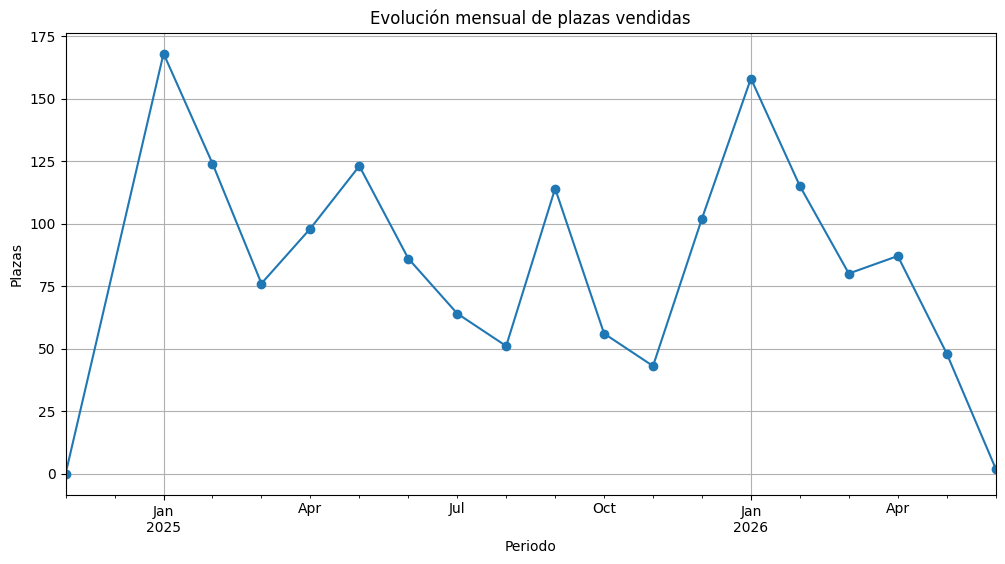

In [46]:
plt.figure(figsize=(12,6))

plazas_mensuales.plot(
    marker="o"
)

plt.title(
    "Evolución mensual de plazas vendidas"
)

plt.xlabel("Periodo")

plt.ylabel("Plazas")

plt.grid(True)

plt.show()

In [47]:
resumen_temporal = pd.DataFrame({
    "Facturacion": facturacion_mensual,
    "Pedidos": pedidos_mensuales,
    "Plazas": plazas_mensuales
})

resumen_temporal.head()

,Facturacion,Pedidos,Plazas
Periodo,,,
2024-11,150.0,1,0
2025-01,14993.0,144,168
2025-02,9050.0,82,124
2025-03,8500.0,78,76
2025-04,8560.0,80,98


# 4. Resultados de los modelos predictivos

Una vez analizada la evolución histórica del negocio, se incorporan los resultados obtenidos en los modelos de predicción desarrollados en los notebooks anteriores.

Estos modelos permiten estimar tanto la demanda futura como la ocupación esperada de los talleres, proporcionando información relevante para la posterior optimización del calendario anual.
### Predicción de demanda

Se evaluaron distintos modelos de Machine Learning con el objetivo de estimar la demanda futura de la empresa. Los resultados mostraron una elevada capacidad predictiva cuando se incorporan variables relacionadas con el comportamiento de compra de los clientes.

In [48]:
resultados_demanda = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal",
        "Random Forest",
        "XGBoost"
    ],
    "R²": [
        0.807,
        0.850,
        0.847
    ],
    "MAE": [
        0.338,
        0.172,
        0.194
    ],
    "RMSE": [
        0.514,
        0.453,
        0.457
    ]
})

resultados_demanda

,Modelo,R²,MAE,RMSE
0,Regresión Lineal,0.807,0.338,0.514
1,Random Forest,0.850,0.172,0.453
2,XGBoost,0.847,0.194,0.457


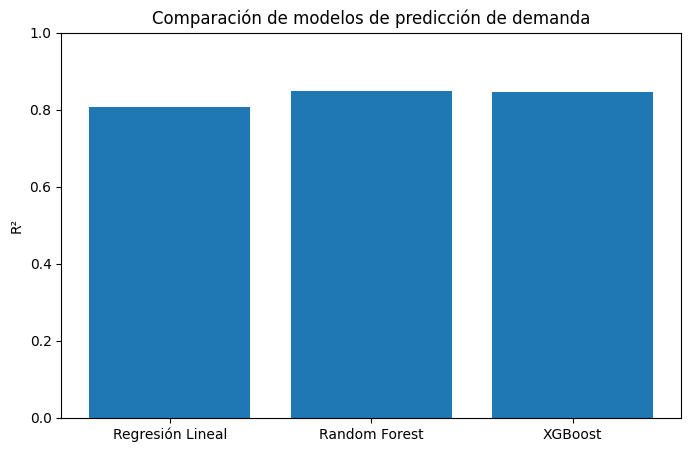

In [49]:
plt.figure(figsize=(8,5))

plt.bar(
    resultados_demanda["Modelo"],
    resultados_demanda["R²"]
)

plt.title(
    "Comparación de modelos de predicción de demanda"
)

plt.ylabel("R²")

plt.ylim(0,1)

plt.show()

Los resultados obtenidos muestran un elevado nivel de precisión en la predicción de la demanda. El modelo Random Forest obtuvo el mejor rendimiento, alcanzando un coeficiente de determinación (R²) de 0,850, seguido muy de cerca por XGBoost con un valor de 0,847.

La Regresión Lineal también presentó resultados satisfactorios, con un R² de 0,807, lo que indica que una parte importante de la variabilidad de la demanda puede explicarse mediante las variables consideradas.

Dado que Random Forest presentó simultáneamente el mayor valor de R² y los menores errores MAE y RMSE, se seleccionó como modelo de referencia para la estimación de la demanda futura y el apoyo a la toma de decisiones.


In [50]:
comparativa_modelos = pd.DataFrame({
    "Modelo": [
        "Predicción de Demanda",
        "Predicción de Ocupación"
    ],
    "R²": [
        0.850,
        0.275282
    ]
})

comparativa_modelos

,Modelo,R²
0,Predicción de Demanda,0.850000
1,Predicción de Ocupación,0.275282


### Predicción de ocupación

Además de la demanda general, se desarrolló un modelo orientado a estimar la ocupación de los talleres.

Aunque la capacidad predictiva obtenida fue inferior a la observada en el modelo de demanda, los resultados permiten identificar patrones relevantes para la planificación y programación de actividades.

In [51]:
resultados_ocupacion = pd.read_excel(
    "resultados_ocupacion.xlsx"
)

resultados_ocupacion

,Modelo,R²,MAE,RMSE
0,Regresión Lineal,0.275282,4.655608,5.661999
1,Random Forest,0.176343,5.050950,6.036128
2,XGBoost,-0.053687,5.554193,6.827175


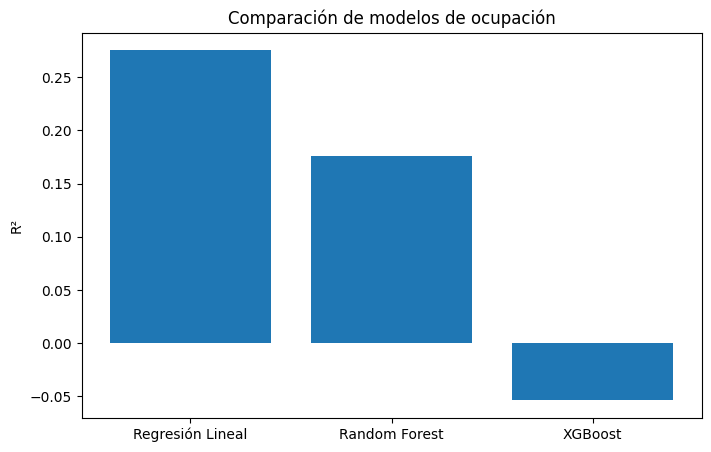

In [52]:
plt.figure(figsize=(8,5))

plt.bar(
    resultados_ocupacion["Modelo"],
    resultados_ocupacion["R²"]
)

plt.title(
    "Comparación de modelos de ocupación"
)

plt.ylabel("R²")

plt.show()

Los modelos desarrollados para la predicción de la ocupación de los talleres mostraron una capacidad predictiva limitada. La Regresión Lineal obtuvo el mejor rendimiento, alcanzando un coeficiente de determinación (R²) de 0,275, mientras que Random Forest y XGBoost presentaron resultados inferiores.

Estos resultados sugieren que la ocupación depende de múltiples factores externos no recogidos en la base de datos analizada, tales como campañas de marketing, condiciones meteorológicas, eventos locales, tendencias gastronómicas o cambios en las preferencias de los clientes.

Por este motivo, los modelos de ocupación no se consideran suficientemente precisos para realizar predicciones operativas fiables, aunque sí permiten identificar tendencias generales de comportamiento. En consecuencia, la planificación y optimización del calendario anual se apoyan principalmente en los resultados obtenidos en el modelo de predicción de demanda.


### Comparativa global

In [53]:
comparativa_modelos = pd.DataFrame({
    "Problema": [
        "Predicción de Demanda",
        "Predicción de Ocupación"
    ],
    "Mejor R²": [
        0.850,
        0.275
    ]
})

comparativa_modelos

,Problema,Mejor R²
0,Predicción de Demanda,0.850
1,Predicción de Ocupación,0.275


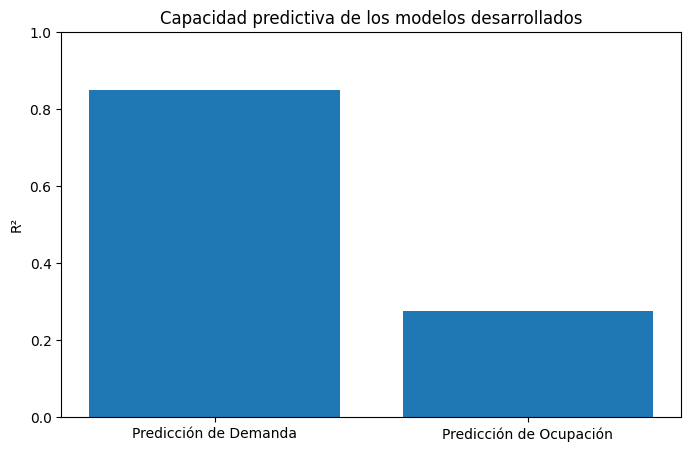

In [54]:
plt.figure(figsize=(8,5))

plt.bar(
    comparativa_modelos["Problema"],
    comparativa_modelos["Mejor R²"]
)

plt.title(
    "Capacidad predictiva de los modelos desarrollados"
)

plt.ylabel("R²")

plt.ylim(0,1)

plt.show()

# 5. Calendario optimizado mediante Gurobi


A partir de los resultados obtenidos en los modelos predictivos y del análisis histórico de la demanda, se desarrolló un modelo de optimización matemática utilizando Gurobi.

El objetivo consistió en generar un calendario anual de talleres que maximizara la asistencia esperada, respetando simultáneamente las restricciones operativas y comerciales definidas por la empresa.

In [55]:
calendario = pd.read_excel(
    "Calendario_Optimizado_FoodFun_2026.xlsx"
)

calendario.head()

,Semana,Dia,Taller
0,1,Lunes,Ramen
1,1,Viernes,Kimchi
2,1,Sabado,Curso de Arroces
3,2,Lunes,Curso de Arroces
4,2,Viernes,Kimchi


## 5.1 Indicadores clave del calendario optimizado

Se calculan los principales indicadores derivados del calendario anual generado mediante Gurobi.

In [56]:
num_sesiones = len(calendario)

num_semanas = calendario["Semana"].nunique()

num_talleres = calendario["Taller"].nunique()

kpis_calendario = pd.DataFrame({
    "Indicador": [
        "Sesiones programadas",
        "Semanas planificadas",
        "Talleres distintos"
    ],
    "Valor": [
        num_sesiones,
        num_semanas,
        num_talleres
    ]
})

kpis_calendario

,Indicador,Valor
0,Sesiones programadas,156
1,Semanas planificadas,52
2,Talleres distintos,9


## 5.2 Distribución anual de talleres

In [57]:
distribucion_talleres = (
    calendario["Taller"]
    .value_counts()
    .reset_index()
)

distribucion_talleres.columns = [
    "Taller",
    "Numero_Sesiones"
]

distribucion_talleres

,Taller,Numero_Sesiones
0,Curso de Arroces,52
1,Ramen,26
2,Kimchi,26
3,Tapas Españolas,12
4,Paella Lovers,12
5,Sushi,10
6,Reposteria,6
7,Taller de Pasta Fresca,6
8,Taller de Principiantes,6


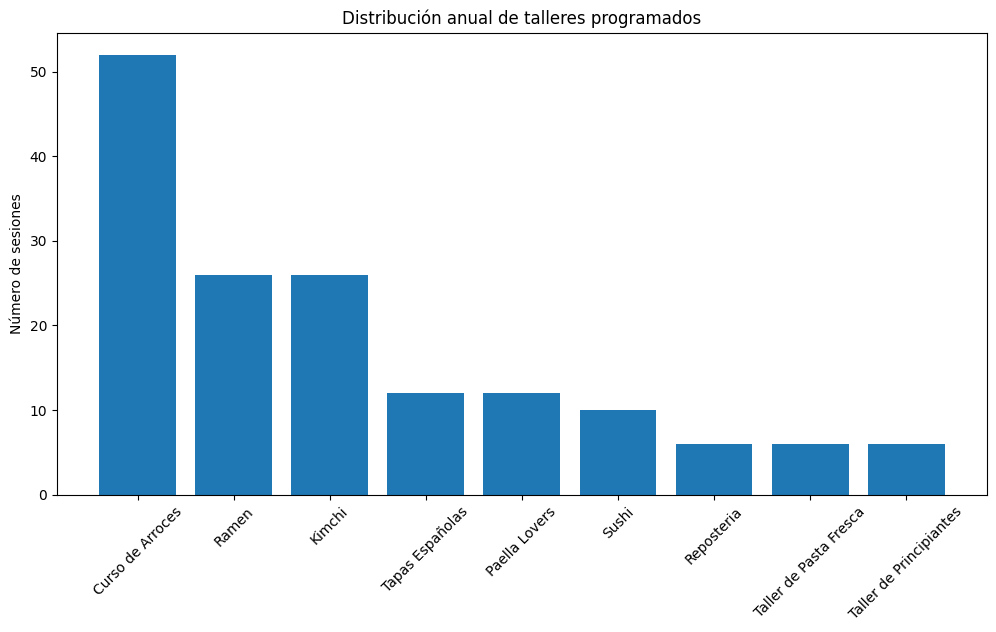

In [58]:
plt.figure(figsize=(12,6))

plt.bar(
    distribucion_talleres["Taller"],
    distribucion_talleres["Numero_Sesiones"]
)

plt.title(
    "Distribución anual de talleres programados"
)

plt.ylabel("Número de sesiones")

plt.xticks(rotation=45)

plt.show()

## 5.3 Distribución por día de la semana

In [59]:
dias = (
    calendario["Dia"]
    .value_counts()
)

dias

Dia
Lunes      52
Viernes    52
Sabado     52
Name: count, dtype: int64

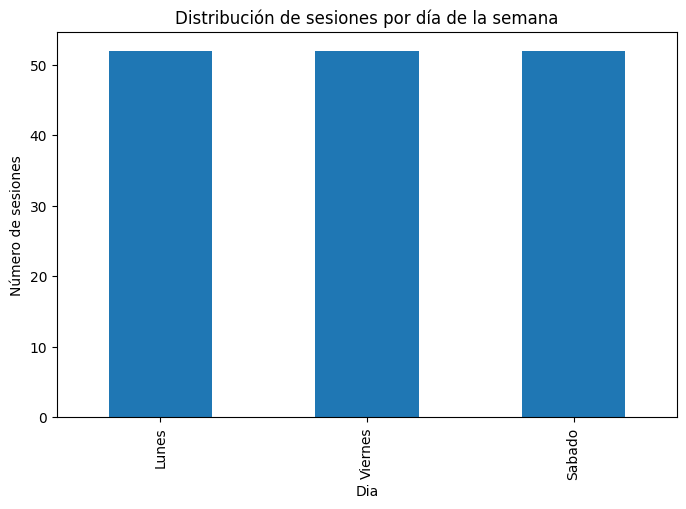

In [60]:
plt.figure(figsize=(8,5))

dias.plot(
    kind="bar"
)

plt.title(
    "Distribución de sesiones por día de la semana"
)

plt.ylabel("Número de sesiones")

plt.show()

## 5.4 Calendario anual generado

El siguiente calendario recoge la programación anual obtenida mediante el modelo de optimización matemática desarrollado en Gurobi.

In [61]:
calendario.head(20)

,Semana,Dia,Taller
0,1,Lunes,Ramen
1,1,Viernes,Kimchi
2,1,Sabado,Curso de Arroces
3,2,Lunes,Curso de Arroces
4,2,Viernes,Kimchi
5,2,Sabado,Ramen
6,3,Lunes,Curso de Arroces
7,3,Viernes,Kimchi
8,3,Sabado,Ramen
9,4,Lunes,Curso de Arroces


## 5.5 Exportación para Streamlit

In [62]:
kpis_calendario.to_excel(
    "dashboard_kpis.xlsx",
    index=False
)

distribucion_talleres.to_excel(
    "distribucion_talleres.xlsx",
    index=False
)

# 6. Conclusiones

El análisis realizado permitió desarrollar un sistema integral de apoyo a la toma de decisiones para Food&Fun.

Los modelos de predicción de demanda alcanzaron niveles elevados de precisión, obteniendo un coeficiente de determinación máximo de 0,850 mediante Random Forest. Por el contrario, los modelos de ocupación mostraron una capacidad predictiva limitada, lo que sugiere la existencia de factores externos no recogidos en la base de datos disponible.

Finalmente, los resultados obtenidos se utilizaron como base para la construcción de un modelo de optimización matemática mediante Gurobi, capaz de generar un calendario anual de talleres alineado con las restricciones operativas y comerciales de la empresa.

La integración de análisis descriptivo, Machine Learning y optimización matemática proporciona una herramienta de gran utilidad para la planificación estratégica de la actividad de Food&Fun.